In [1]:
import ase.io
import matplotlib.pyplot as plt
from ase.io import read
from fairchem.core.datasets.ase_datasets import AseDBDataset
import os
import glob
from ase.io import Trajectory
import matplotlib.pyplot as plt


/u/iamin/miniconda3/envs/fairchemV2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from ase.io import Trajectory
import nglview as nv

path = '/projects/beye/iamin/distillation_project/escaip_trajs/naotf_tgdme.traj'
traj = Trajectory(path)

for atoms in traj:
    atoms.wrap(center=(0.5, 0.5, 0.5))  # recenters and wraps into the cell

atoms = traj[0]
print(atoms.cell)
print(atoms.get_pbc())
print(atoms.positions.min(axis=0), atoms.positions.max(axis=0))


view = nv.show_asetraj(traj)
view.add_unitcell()
view


NGLWidget(max_frame=10890)

In [1]:
#!/usr/bin/env python3
import os
from ase.io.trajectory import Trajectory

parent = "/projects/beye/iamin/distillation_project/500ps_data_ckpt_323K"

for folder in os.listdir(parent):
    folder_path = os.path.join(parent, folder)
    if os.path.isdir(folder_path):
        for f in os.listdir(folder_path):
            if f.endswith(".traj"):
                traj_path = os.path.join(folder_path, f)
                try:
                    nframes = len(Trajectory(traj_path))  # lazy, no full load
                    print(f"{traj_path}: {nframes} frames")
                except Exception as e:
                    print(f"{traj_path}: error ({e})")


/projects/beye/iamin/distillation_project/500ps_data_ckpt_323K/md_omol_naotf_tgdme_1m_s1p1/md_omol_naotf_tgdme_1m_s1p1.traj: 42829 frames
/projects/beye/iamin/distillation_project/500ps_data_ckpt_323K/md_omol_naotf_dme_s1p1_omol/md_omol_naotf_dme_s1p1_omol.traj: 53214 frames
/projects/beye/iamin/distillation_project/500ps_data_ckpt_323K/md_omol_naotf_diglyme_1m_s1p1/md_omol_naotf_diglyme_1m_s1p1.traj: 47018 frames
/projects/beye/iamin/distillation_project/500ps_data_ckpt_323K/md_omol_naotf_pc_1m_s1p1/md_omol_naotf_pc_1m_s1p1.traj: 51057 frames


In [ ]:
# Load AseDBDataset
a2g_args = {  
    "r_energy": True,
    "r_forces": True,
    "r_stress": True,
    "r_data_keys": ['spin', 'charge']
}
path = '/global/cfs/cdirs/m4558/aug_29_first_100ps/combined/train'
path = '/global/cfs/cdirs/m4558/distillation_project/all_lmdbs/combined/train'
# path = '/projects/beye/iamin/distillation_project/all_lmdbs/combined/train'
path = '/projects/beye/distillation_project/xyzs/'

dataset = AseDBDataset({
                        "src": path,
                        "a2g_args": a2g_args,
                        })


print(len(dataset))
for i in range(30):
    print(dataset[0].cell)

13500
tensor([[[28.5579,  0.0000,  0.0000],
         [ 0.0000, 28.5579,  0.0000],
         [ 0.0000,  0.0000, 28.5579]]])
tensor([[[28.5579,  0.0000,  0.0000],
         [ 0.0000, 28.5579,  0.0000],
         [ 0.0000,  0.0000, 28.5579]]])
tensor([[[28.5579,  0.0000,  0.0000],
         [ 0.0000, 28.5579,  0.0000],
         [ 0.0000,  0.0000, 28.5579]]])
tensor([[[28.5579,  0.0000,  0.0000],
         [ 0.0000, 28.5579,  0.0000],
         [ 0.0000,  0.0000, 28.5579]]])
tensor([[[28.5579,  0.0000,  0.0000],
         [ 0.0000, 28.5579,  0.0000],
         [ 0.0000,  0.0000, 28.5579]]])
tensor([[[28.5579,  0.0000,  0.0000],
         [ 0.0000, 28.5579,  0.0000],
         [ 0.0000,  0.0000, 28.5579]]])
tensor([[[28.5579,  0.0000,  0.0000],
         [ 0.0000, 28.5579,  0.0000],
         [ 0.0000,  0.0000, 28.5579]]])
tensor([[[28.5579,  0.0000,  0.0000],
         [ 0.0000, 28.5579,  0.0000],
         [ 0.0000,  0.0000, 28.5579]]])
tensor([[[28.5579,  0.0000,  0.0000],
         [ 0.0000, 28.5579, 

In [4]:

root = '/global/cfs/cdirs/m4558/first_100ps_traj_to_send/'
root = '/global/cfs/cdirs/m4558/distillation_project/all_trajs_min50ps'
# root = '/global/cfs/cdirs/m4558/distillation_project/all_xyzs/per_systems/naotf_pc/train'
root = '/global/cfs/cdirs/m4558/distillation_project/all_xyzs/per_systems/cspf6/train'
root = '/global/cfs/cdirs/m4558/distillation_project/all_xyzs/combined/train'
for fname in os.listdir(root):
    if fname.endswith(".traj") or fname.endswith(".xyz"):
        path = os.path.join(root, fname)
        try:
            # Lazily read just the first frame
            atoms = read(path, index=0)
            print(atoms.calc)
            # energy = atoms.get_potential_energy()
            # print(f"{fname}: GOOD (energy = {energy})")
            print(atoms.info)
        except Exception as e:
            print(f"{fname}: potential energies not found ({e})")

FileNotFoundError: [Errno 2] No such file or directory: '/global/cfs/cdirs/m4558/distillation_project/all_xyzs/combined/train'

In [ ]:
import glob
from ase.io.trajectory import Trajectory

folder = '/global/cfs/cdirs/m4558/distillation_project/all_trajs_min50ps/'

for fname in sorted(glob.glob(folder + "*.traj")):
    try:
        # ASE loads lazily, so this won’t pull in all frames
        traj = Trajectory(fname)
        print(f"{os.path.basename(fname)}: {len(traj)} frames")
    except Exception as e:
        print(f"Could not read {fname}: {e}")


md_omol_napf6_diglyme_pfactor_0.1_1fs.traj: 10966 frames
md_omol_napf6_dme_re1.traj: 10001 frames


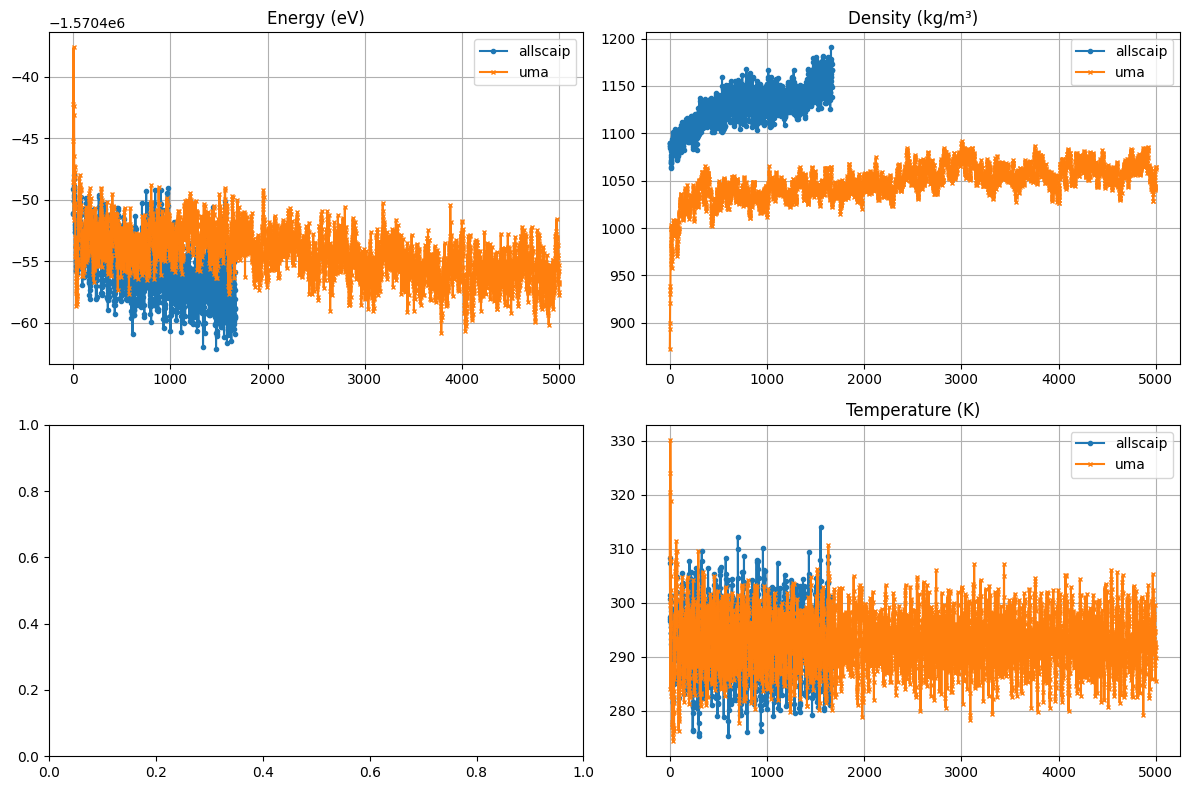

In [11]:
from ase.io import read
import matplotlib.pyplot as plt
import numpy as np

# File paths
path1 = '/projects/beye/iamin/distillation_project/escaip_trajs_15A_cutoff/naotf_dme.traj'
path2 = '/projects/beye/iamin/distillation_project/UMA_trajs_293K/naotf_dme.traj'

# Load frames (first 50)
traj1 = read(path1, index=':5000')
traj2 = read(path2, index=':5000')

# Energies
energies1 = [a.get_potential_energy() for a in traj1]
energies2 = [a.get_potential_energy() for a in traj2]

# Volumes → Densities
def density(atoms):
    # mass in g/mol → convert to kg
    molar_mass = atoms.get_masses().sum() / 1000.0
    # Avogadro's number
    NA = 6.02214076e23
    mass_kg = molar_mass / NA
    vol_m3 = atoms.get_volume() * 1e-30
    return mass_kg / vol_m3  # kg/m³

densities1 = [density(a) for a in traj1]
densities2 = [density(a) for a in traj2]

# Pressure & Temperature (ASE stores these in calculator stress/temperature if available)
# pressures1 = [a.get_pressure() for a in traj1]
# pressures2 = [a.get_pressure() for a in traj2]
temps1 = [a.get_temperature() for a in traj1]
temps2 = [a.get_temperature() for a in traj2]

# Plot all in subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
frames = range(len(traj1))
frames2 = range(len(traj2))

axs[0,0].plot(frames, energies1, "o-", ms=3, label="allscaip")
axs[0,0].plot(frames2, energies2, "x-", ms=3, label="uma")
axs[0,0].set_title("Energy (eV)"); axs[0,0].legend(); axs[0,0].grid(True)

axs[0,1].plot(frames, densities1, "o-", ms=3, label="allscaip")
axs[0,1].plot(frames2, densities2, "x-", ms=3, label="uma")
axs[0,1].set_title("Density (kg/m³)"); axs[0,1].legend(); axs[0,1].grid(True)

# axs[1,0].plot(frames, pressures1, "o-", ms=3, label="Normal")
# axs[1,0].plot(frames2, pressures2, "x-", ms=3, label="15A Mask")
# axs[1,0].set_title("Pressure (Pa)"); axs[1,0].legend(); axs[1,0].grid(True)

axs[1,1].plot(frames, temps1, "o-", ms=3, label="allscaip")
axs[1,1].plot(frames2, temps2, "x-", ms=3, label="uma")
axs[1,1].set_title("Temperature (K)"); axs[1,1].legend(); axs[1,1].grid(True)

plt.tight_layout()
plt.show()


Finished distilled traj


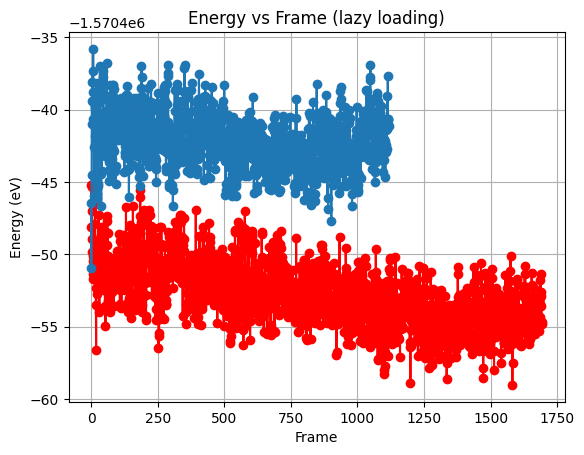

In [7]:
# Load ASE trajectory
# Load the trajectory
from ase.io import iread
import matplotlib.pyplot as plt
path = '/projects/beye/iamin/distillation_project/distilled_trajs/naotf_dme_test.traj'


energies = []
for atoms in iread(path, index=":"):
    energies.append(atoms.get_potential_energy())
print("Finished distilled traj")
uma_traj = '/projects/beye/iamin/distillation_project/all_trajs_min_50ps/md_omol_naotf_dme_s1p1_omol.traj'
uma_energies = []
i = 0
for atoms in iread(uma_traj, index=":"):
    # if i // 5 >= len(energies):
    #     break
    if i % 5 == 0:
        uma_energies.append(atoms.get_potential_energy())
    i += 1

plt.plot(range(len(uma_energies)), uma_energies, marker="o", linestyle="-", color='red')
plt.plot(range(len(energies)), energies, marker="o", linestyle="-")
plt.xlabel("Frame")
plt.ylabel("Energy (eV)")
plt.title("Energy vs Frame (lazy loading)")
plt.grid(True)
plt.show()
